# Title: Student-Performance


In [1]:
#code:import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dataset Description

The dataset used in this project is the Student Performance Dataset obtained from the UCI Machine Learning Repository.

The dataset contains information about students and their academic performance.

### Important Features

- School and demographic information
- Study time
- Previous failures
- Absences
- Family and social factors
- First period grade (G1)
- Second period grade (G2)
- Final grade (G3)

### Target Variable

The final grade (G3) is used to determine the student's performance.

The dataset contains student records with multiple academic and personal attributes, which can be used to build a machine learning model for predicting student performance.

In [4]:
code:load dataset
# Load Student Performance Dataset

!pip -q install ucimlrepo

from ucimlrepo import fetch_ucirepo

# Fetch Student Performance dataset from UCI
student_performance = fetch_ucirepo(id=320)

# Create dataframe
df = student_performance.data.features.copy()

# Add target column
df["final_grade"] = student_performance.data.targets["G3"]

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (649, 31)


In [5]:
#code:view dataset
# Display the First 5 Rows
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,final_grade
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,4,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,2,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,6,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,0,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,0,13


markdown:data understanding
# Data Understanding

Data understanding is the process of examining the dataset to understand its structure, features, data types, and overall characteristics.

In this step, we will:
- Check the number of rows and columns.
- Identify the features available in the dataset.
- Check the data types of each feature.
- Identify missing values.
- Analyze basic statistical information.
- Understand the target variable used for prediction.

In [6]:
#markdown:data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   school       649 non-null    object
 1   sex          649 non-null    object
 2   age          649 non-null    int64 
 3   address      649 non-null    object
 4   famsize      649 non-null    object
 5   Pstatus      649 non-null    object
 6   Medu         649 non-null    int64 
 7   Fedu         649 non-null    int64 
 8   Mjob         649 non-null    object
 9   Fjob         649 non-null    object
 10  reason       649 non-null    object
 11  guardian     649 non-null    object
 12  traveltime   649 non-null    int64 
 13  studytime    649 non-null    int64 
 14  failures     649 non-null    int64 
 15  schoolsup    649 non-null    object
 16  famsup       649 non-null    object
 17  paid         649 non-null    object
 18  activities   649 non-null    object
 19  nursery      649 non-null    

In [8]:
#check for missing values
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [9]:
# Display Statistical Summary
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,final_grade
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000


#EDA Introduction
# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to understand the patterns, relationships, and distributions present in the dataset.

In this step, we will visualize important features and analyze how they are related to student performance.

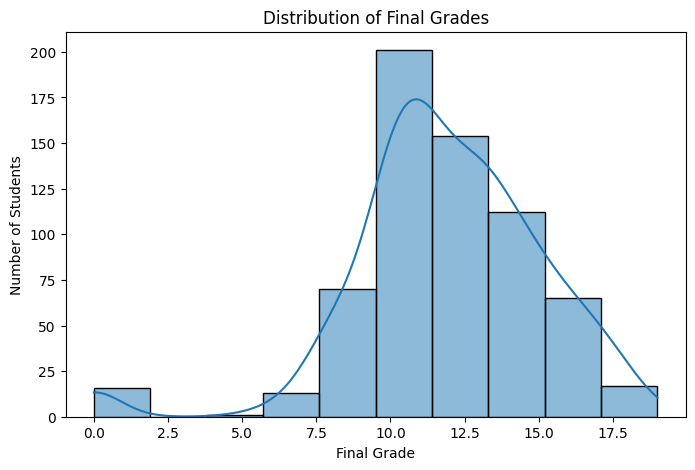

In [10]:
# target variable distribution
# Visualize Final Grade Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["final_grade"], bins=10, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

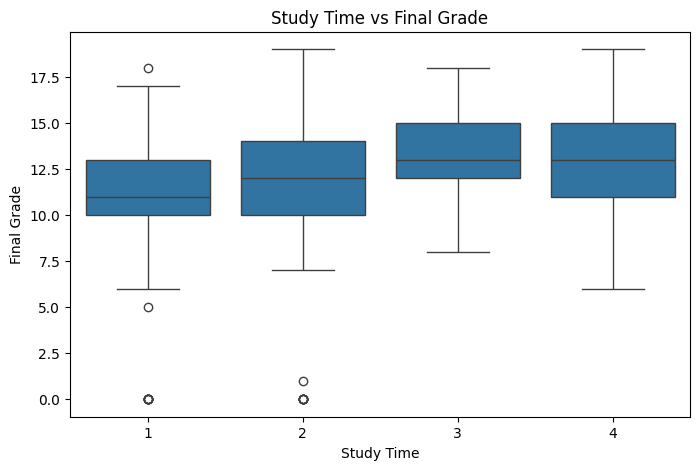

In [11]:
#Study Time vs Final Grade
# Analyze Study Time vs Final Grade

plt.figure(figsize=(8, 5))
sns.boxplot(x="studytime", y="final_grade", data=df)

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.show()

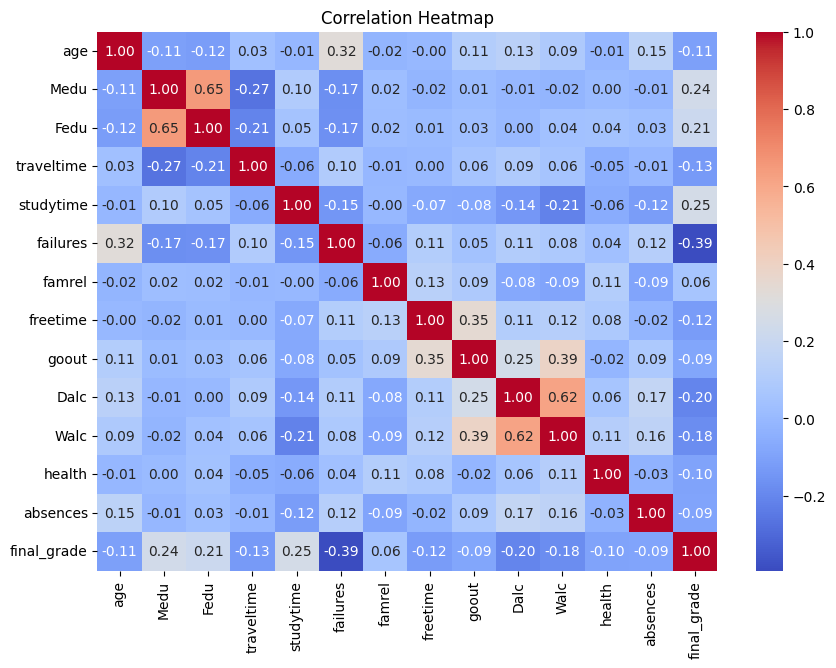

In [12]:
# correlation Analysis
# Analyze Correlation Between Numerical Features

plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [16]:
#display all column names clearly
print(*df.columns,sep="\n")

school
sex
age
address
famsize
Pstatus
Medu
Fedu
Mjob
Fjob
reason
guardian
traveltime
studytime
failures
schoolsup
famsup
paid
activities
nursery
higher
internet
romantic
famrel
freetime
goout
Dalc
Walc
health
absences
final_grade


In [14]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'final_grade']


In [17]:
#feature selection
# Select Features and Target Variable

df.columns = df.columns.str.strip()

features = ["studytime", "failures", "absences"]

X = df[features]

# Use the last column as the target variable
target = df.columns[-1]
y = df[target]

print("Features:", features)
print("Target:", target)

Features: ['studytime', 'failures', 'absences']
Target: final_grade


In [18]:
# Train-Test Split
# Split Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 519
Testing samples: 130


In [19]:
#Feature Scaling
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [20]:
#Train KnN Model
# Train KNN Regression Model

from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [21]:
# Make Predictions
# Make Predictions on Test Data

y_pred = knn.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[12.  11.4 11.2 12.  11.4 14.4 11.2  8.8 12.4 12. ]


In [22]:
# Model Evaluation
# Evaluate KNN Model

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Evaluation")
print("-----------------")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Model Evaluation
-----------------
Mean Absolute Error (MAE): 2.38
Root Mean Squared Error (RMSE): 3.15


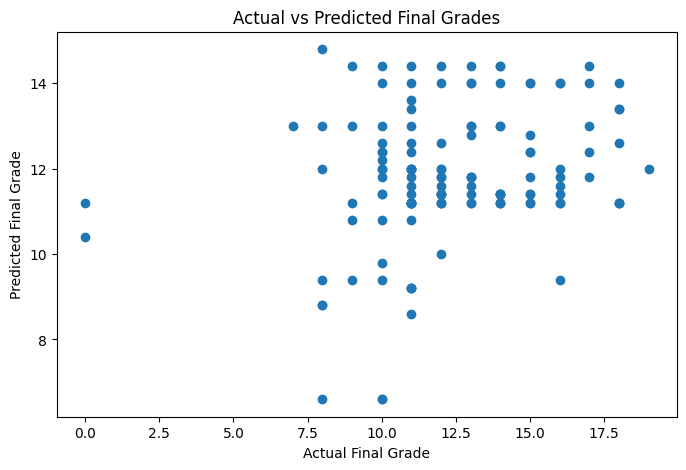

In [23]:
# Actual VS Predicted Grades
# Visualize Actual vs Predicted Grades

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Final Grades")

plt.show()

In [24]:
# Model Performance Summary
# Model Performance Summary

print("KNN Model Performance")
print("---------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

print("\nInterpretation:")
print("Lower MAE and RMSE values indicate better prediction performance.")

KNN Model Performance
---------------------
MAE  : 2.38
RMSE : 3.15

Interpretation:
Lower MAE and RMSE values indicate better prediction performance.


In [25]:
# Prediction of New Student's Performance
# Predict Performance for a New Student

new_student = pd.DataFrame({
    "studytime": [3],
    "failures": [0],
    "absences": [5]
})

# Scale the new student's data
new_student_scaled = scaler.transform(new_student)

# Make prediction
prediction = knn.predict(new_student_scaled)

print("Predicted Final Grade:", round(prediction[0], 2))

Predicted Final Grade: 14.8


In [26]:
# Performance Category
# Convert Predicted Grade into Performance Category

predicted_grade = prediction[0]

if predicted_grade >= 15:
    category = "Excellent"
elif predicted_grade >= 10:
    category = "Good"
elif predicted_grade >= 5:
    category = "Average"
else:
    category = "Poor"

print("Predicted Final Grade:", round(predicted_grade, 2))
print("Performance Category:", category)

Predicted Final Grade: 14.8
Performance Category: Good


# Conclusion

In this project, the K-Nearest Neighbors (KNN) algorithm was used to predict student academic performance.

The dataset was analyzed and preprocessed before training the model. Important features such as study time, previous failures, and absences were selected for prediction.

The KNN model was trained using the training data and evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The model was also used to predict the performance of a new student.

Overall, this project demonstrates how machine learning can be applied to analyze student-related data and predict academic performance.

# Project Summary

### Algorithm Used
K-Nearest Neighbors (KNN) Regression

### Input Features
- Study Time
- Previous Failures
- Absences

### Target
Student Final Grade

### Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

### Tools & Technologies
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Project Outcome
The KNN model predicts student academic performance based on selected student-related features and provides a predicted final grade and performance category.

In [27]:
# Verify Target Variable

print("Target column:", target)
print("\nFirst 10 target values:")
print(y.head(10))

print("\nTarget data type:", y.dtype)

Target column: final_grade

First 10 target values:
0    11
1    11
2    12
3    14
4    13
5    13
6    13
7    13
8    17
9    13
Name: final_grade, dtype: int64

Target data type: int64
